# Math Lab Notebook
## Session 1: Seeing Algebra as a System

Goal:
To understand how equations behave, not just how to solve them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return 2*x + 1

def f2(x):
    return 2*x + 2

In [3]:
x = np.linspace(-10, 10, 100)
y1 = f(x)
y2 = f2(x)

## Linear Equation Form

$y = mx + b$

- $m$ = slope (how steep the line is)
- $b$ = vertical shift (where it crosses the y-axis)

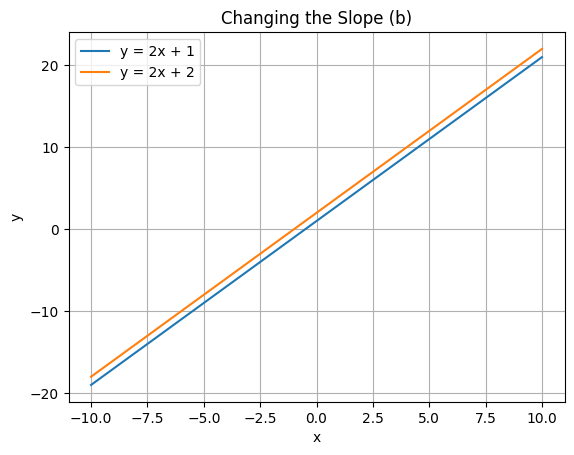

In [4]:
plt.plot(x, y1, label="y = 2x + 1")
plt.plot(x, y2, label="y = 2x + 2")

plt.title("Changing the Slope (b)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

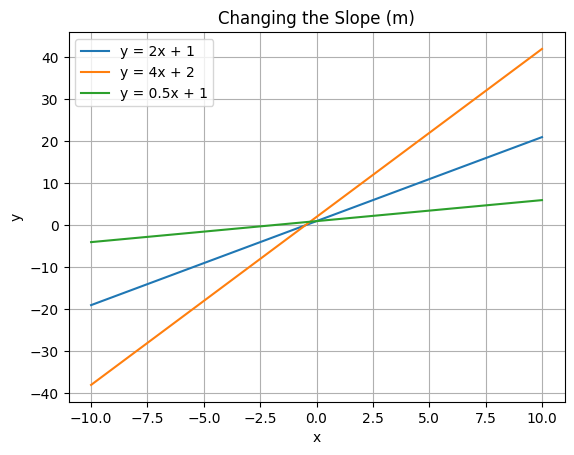

In [5]:
def f1(x):
    return 2*x + 1

def f2(x):
    return 4*x + 2

def f3(x):
    return 0.5*x + 1

x = np.linspace(-10, 10, 100)

y1 = f1(x)
y2 = f2(x)
y3 = f3(x)

plt.plot(x, y1, label="y = 2x + 1")
plt.plot(x, y2, label="y = 4x + 2")
plt.plot(x, y3, label="y = 0.5x + 1")

plt.title("Changing the Slope (m)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

# Reflection

A linear equation is a rule that transforms input into output at a constant rate.

This is the simplest form of change.

# Wave Lab

Now we move from lines → waves

This connects directly to signals and FFT.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def wave(freq=1.0, amplitude=1.0):
    x = np.linspace(0, 2*np.pi, 500)
    y = amplitude * np.sin(freq * x)

    plt.figure(figsize=(8,4))
    plt.plot(x, y)
    plt.title(f"Sine Wave | freq={freq}, amplitude={amplitude}")
    plt.xlabel("x (time)")
    plt.ylabel("y (signal)")
    plt.grid()
    plt.show()

In [13]:
interact(wave, freq=(0.5, 10.0, 0.5), amplitude=(0.5, 5.0, 0.5))

interactive(children=(FloatSlider(value=1.0, description='freq', max=10.0, min=0.5, step=0.5), FloatSlider(val…

<function __main__.wave(freq=1.0, amplitude=1.0)>

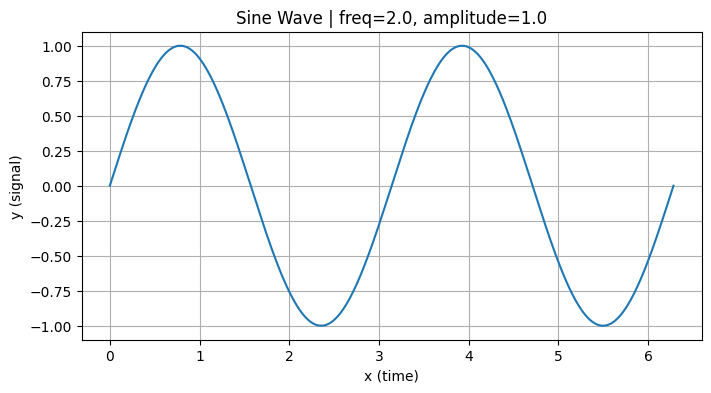

In [17]:
wave(freq=2.0, amplitude=1.0)

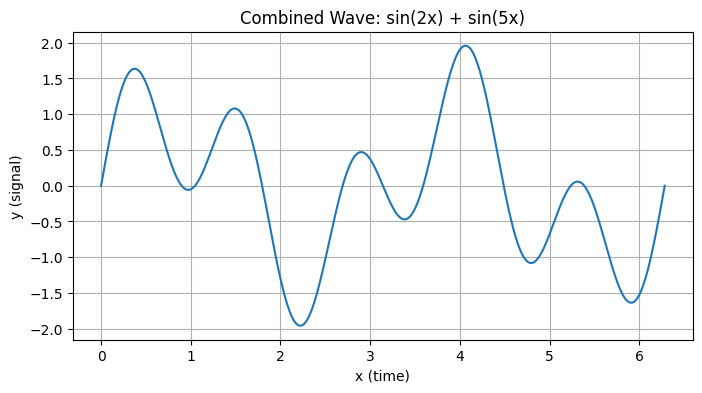

In [21]:
x = np.linspace(0, 2*np.pi, 500)
y = np.sin(2*x) + np.sin(5*x)

plt.figure(figsize=(8,4))
plt.plot(x, y)
plt.title("Combined Wave: sin(2x) + sin(5x)")
plt.xlabel("x (time)")
plt.ylabel("y (signal)")
plt.grid()
plt.show()

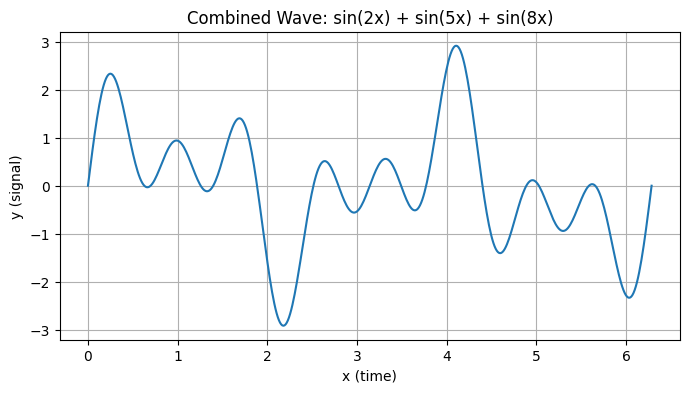

In [23]:
x = np.linspace(0, 2*np.pi, 500)
y = np.sin(2*x) + np.sin(5*x) + np.sin(8*x)

plt.figure(figsize=(8,4))
plt.plot(x, y)
plt.title("Combined Wave: sin(2x) + sin(5x) + sin(8x)")
plt.xlabel("x (time)")
plt.ylabel("y (signal)")
plt.grid()
plt.show()

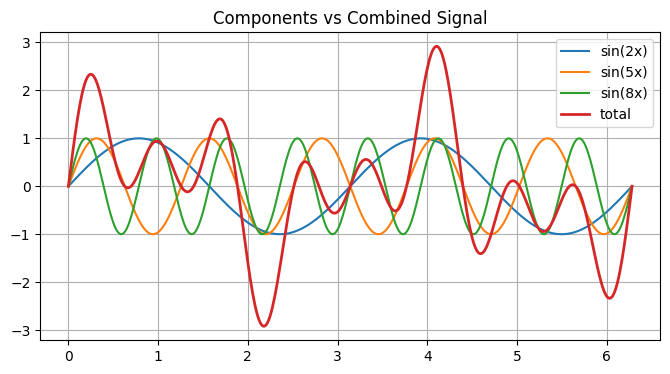

In [24]:
x = np.linspace(0, 2*np.pi, 500)

y1 = np.sin(2*x)
y2 = np.sin(5*x)
y3 = np.sin(8*x)
y_total = y1 + y2 + y3

plt.figure(figsize=(8,4))
plt.plot(x, y1, label="sin(2x)")
plt.plot(x, y2, label="sin(5x)")
plt.plot(x, y3, label="sin(8x)")
plt.plot(x, y_total, label="total", linewidth=2)

plt.legend()
plt.grid()
plt.title("Components vs Combined Signal")
plt.show()

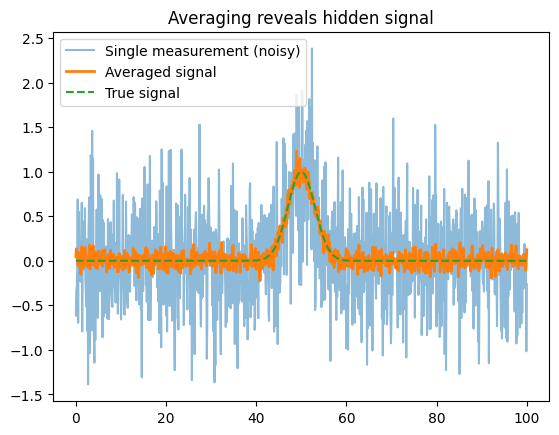

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create x-axis (frequency-like)
x = np.linspace(0, 100, 1000)

# Hidden signal (a small bump)
true_signal = np.exp(-0.5*((x-50)/3)**2)

# Add noise
def noisy_measurement():
    noise = np.random.normal(0, 0.5, size=x.shape)
    return true_signal + noise

# Take multiple measurements and average
N = 50
measurements = np.array([noisy_measurement() for _ in range(N)])
average = np.mean(measurements, axis=0)

# Plot
plt.figure()
plt.plot(x, measurements[0], label="Single measurement (noisy)", alpha=0.5)
plt.plot(x, average, label="Averaged signal", linewidth=2)
plt.plot(x, true_signal, label="True signal", linestyle="dashed")
plt.legend()
plt.title("Averaging reveals hidden signal")
plt.show()

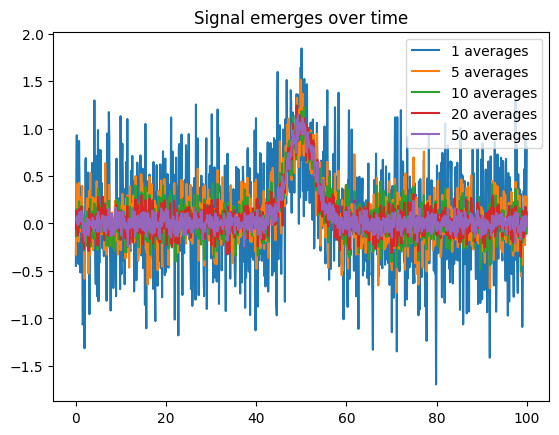

In [2]:
running_average = np.zeros_like(x)

plt.figure()

for i in range(1, 51):
    new_data = noisy_measurement()
    running_average = ((i-1)*running_average + new_data) / i
    
    if i in [1, 5, 10, 20, 50]:
        plt.plot(x, running_average, label=f"{i} averages")

plt.legend()
plt.title("Signal emerges over time")
plt.show()

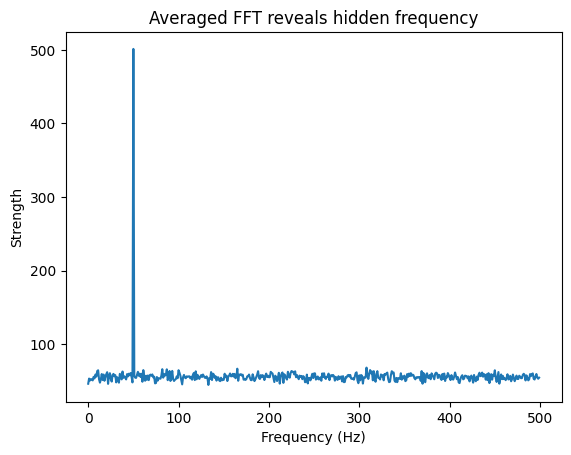

In [12]:
# Simulate time-domain signal
fs = 1000  # sample rate
t = np.arange(0, 1, 1/fs)

def get_signal():
    freq = 50  # hidden frequency
    signal = np.sin(2*np.pi*freq*t)
    noise = np.random.normal(0, 2, size=t.shape)
    return signal + noise

def compute_fft(signal):
    fft = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    return freqs[:len(freqs)//2], np.abs(fft[:len(fft)//2])

# Average FFTs
N = 50
avg_fft = None

for i in range(N):
    sig = get_signal()
    freqs, fft_vals = compute_fft(sig)
    
    if avg_fft is None:
        avg_fft = fft_vals
    else:
        avg_fft = (avg_fft*i + fft_vals)/(i+1)

# Plot
plt.figure()
plt.plot(freqs, avg_fft)
plt.title("Averaged FFT reveals hidden frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strength")
plt.show()

In [ ]:
#averaging is noise is average so it cancels out, a signal is consistant so it stays